Optimal threshold μ1 (equal cost) = 5.341670835417709
Optimal threshold μ2 (high penalty) = 5.522461230615308


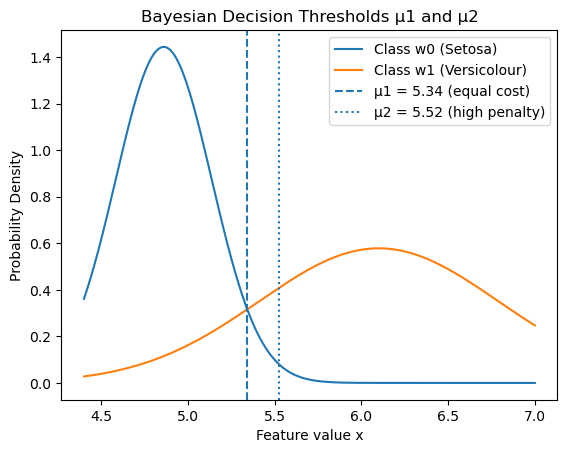


x	P(w0|x)	P(w1|x)	g(x)	Class
3.3	0.001		0.999		0.0001	1
4.4	0.929		0.071		-0.1668	0
1.2	0.000		1.000		0.0000	1
5.0	0.887		0.113		-0.5537	0
5.7	0.028		0.972		0.2373	1
6.3	0.000		1.000		0.2772	1
1.5	0.000		1.000		0.0000	1


In [3]:
# =========================================
# ELE 888 – Lab 1
# Bayesian Decision Theory
# μ1 (equal cost) and μ2 (high penalty)
# =========================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Dataset (Setosa = w0, Versicolour = w1)
# Columns: sepal length, sepal width, class
# -----------------------------------------
data = np.array([
    [5.1, 3.5, 0], [4.9, 3.0, 0], [4.7, 3.2, 0], [4.6, 3.1, 0],
    [5.0, 3.6, 0], [5.4, 3.9, 0], [4.6, 3.4, 0], [5.0, 3.4, 0],
    [4.4, 2.9, 0], [4.9, 3.1, 0],

    [7.0, 3.2, 1], [6.4, 3.2, 1], [6.9, 3.1, 1], [5.5, 2.3, 1],
    [6.5, 2.8, 1], [5.7, 2.8, 1], [6.3, 3.3, 1], [4.9, 2.4, 1],
    [6.6, 2.9, 1], [5.2, 2.7, 1]
])

X = data[:, :2]
y = data[:, 2]

# -----------------------------------------
# 2. Choose feature
# 0 = sepal length
# 1 = sepal width
# -----------------------------------------
feature_index = 0
x = X[:, feature_index]

class0 = x[y == 0]   # w0: Setosa
class1 = x[y == 1]   # w1: Versicolour

# -----------------------------------------
# 3. Gaussian parameters + priors
# -----------------------------------------
mu0, sigma0 = np.mean(class0), np.std(class0)
mu1, sigma1 = np.mean(class1), np.std(class1)

P0 = len(class0) / len(x)
P1 = len(class1) / len(x)

# -----------------------------------------
# 4. Gaussian PDF
# -----------------------------------------
def gaussian_pdf(x, mu, sigma):
    return (1 / np.sqrt(2 * np.pi * sigma**2)) * \
           np.exp(-0.5 * ((x - mu) / sigma)**2)

# -----------------------------------------
# 5. Discriminant function g(x)
# -----------------------------------------
def g(x):
    return gaussian_pdf(x, mu1, sigma1) * P1 - \
           gaussian_pdf(x, mu0, sigma0) * P0

# -----------------------------------------
# 6. Compute μ1 (equal cost threshold)
# -----------------------------------------
x_vals = np.linspace(min(class0.min(), class1.min()),
                     max(class0.max(), class1.max()), 2000)

g_vals = np.array([g(xv) for xv in x_vals])

idx1 = np.argmin(np.abs(g_vals))
mu1_threshold = x_vals[idx1]

print("Optimal threshold μ1 (equal cost) =", mu1_threshold)

# -----------------------------------------
# 7. Compute μ2 (high penalty threshold)
# -----------------------------------------
lambda_10 = 5   # high penalty for misclassifying w1 as w0

def g_penalty(x):
    return gaussian_pdf(x, mu1, sigma1) * P1 - \
           lambda_10 * gaussian_pdf(x, mu0, sigma0) * P0

g_penalty_vals = np.array([g_penalty(xv) for xv in x_vals])

idx2 = np.argmin(np.abs(g_penalty_vals))
mu2_threshold = x_vals[idx2]

print("Optimal threshold μ2 (high penalty) =", mu2_threshold)

# -----------------------------------------
# 8. Plot μ1 and μ2
# -----------------------------------------
plt.figure()
plt.plot(x_vals, gaussian_pdf(x_vals, mu0, sigma0), label="Class w0 (Setosa)")
plt.plot(x_vals, gaussian_pdf(x_vals, mu1, sigma1), label="Class w1 (Versicolour)")

plt.axvline(mu1_threshold, linestyle='--',
            label=f"μ1 = {mu1_threshold:.2f} (equal cost)")
plt.axvline(mu2_threshold, linestyle=':',
            label=f"μ2 = {mu2_threshold:.2f} (high penalty)")

plt.xlabel("Feature value x")
plt.ylabel("Probability Density")
plt.title("Bayesian Decision Thresholds μ1 and μ2")
plt.legend()
plt.show()

# -----------------------------------------
# 9. Posterior probabilities + classification
# -----------------------------------------
def posteriors(x):
    p0 = gaussian_pdf(x, mu0, sigma0) * P0
    p1 = gaussian_pdf(x, mu1, sigma1) * P1
    total = p0 + p1
    return p0 / total, p1 / total

def classify_equal_cost(x):
    return 1 if g(x) > 0 else 0

# -----------------------------------------
# 10. Test values table (for report)
# -----------------------------------------
test_x = [3.3, 4.4, 1.2, 5.0, 5.7, 6.3, 1.5]

print("\nx\tP(w0|x)\tP(w1|x)\tg(x)\tClass")
for val in test_x:
    Pw0, Pw1 = posteriors(val)
    print(f"{val:.1f}\t{Pw0:.3f}\t\t{Pw1:.3f}\t\t{g(val):.4f}\t{classify_equal_cost(val)}")
